# 05 – Advanced Analytics
**Bluestock Fintech Mutual Fund Analytics Platform**

Covers: VaR, CVaR, Rolling Sharpe, Cohort Analysis, SIP Continuation, Fund Recommender, Sector Concentration.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
BASE = Path("..").resolve()
PROC = BASE / "data" / "processed"
RPT  = BASE / "reports"
sys.path.insert(0, str(BASE / "scripts"))

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

nav   = pd.read_csv(PROC / "nav_history_clean.csv",        parse_dates=["date"])
sp    = pd.read_csv(PROC / "scheme_performance_clean.csv")
txn   = pd.read_csv(PROC / "investor_transactions_clean.csv", parse_dates=["transaction_date"])
hold  = pd.read_csv(PROC / "portfolio_holdings_clean.csv")
bench = pd.read_csv(PROC / "benchmark_indices_clean.csv",  parse_dates=["date"])
sip   = pd.read_csv(PROC / "monthly_sip_inflows_clean.csv",parse_dates=["month"])
print("Data loaded.")

Data loaded.


## 1. Value at Risk (VaR) & Conditional VaR

In [2]:
from compute_metrics import value_at_risk, conditional_var, rolling_sharpe

var_results = []
for code, grp in nav.groupby("amfi_code"):
    ret = grp["daily_return_pct"].dropna()
    if len(ret) < 60:
        continue
    var_results.append({
        "amfi_code": code,
        "var_95":    value_at_risk(ret, 0.95),
        "cvar_95":   conditional_var(ret, 0.95),
        "var_99":    value_at_risk(ret, 0.99),
        "cvar_99":   conditional_var(ret, 0.99),
        "n_obs":     len(ret)
    })

var_df = pd.DataFrame(var_results).merge(
    sp[["amfi_code","scheme_name","category"]], on="amfi_code", how="left"
)
print(f"VaR computed for {len(var_df)} funds.")
print(var_df[["scheme_name","var_95","cvar_95","var_99","cvar_99"]].head(10).to_string(index=False))
var_df.to_csv(PROC / "fund_var_analysis.csv", index=False)

VaR computed for 40 funds.
                                       scheme_name    var_95   cvar_95    var_99   cvar_99
         HDFC Top 100 Fund - Regular Plan - Growth -1.436364 -1.806021 -2.039222 -2.213815
      HDFC Short Term Debt Fund - Regular - Growth -0.379325 -0.499376 -0.583151 -0.696338
HDFC Mid-Cap Opportunities Fund - Regular - Growth -1.903354 -2.345576 -2.544279 -3.032560
     ABSL Frontline Equity Fund - Regular - Growth -1.328166 -1.743943 -1.964834 -2.474823
            ABSL Small Cap Fund - Regular - Growth -2.602125 -3.245906 -3.707050 -4.208617
               ABSL Liquid Fund - Regular - Growth -0.026866 -0.042208 -0.052709 -0.061974
        UTI Nifty 50 Index Fund - Regular - Growth -1.261263 -1.549041 -1.773212 -1.920458
               UTI Mid Cap Fund - Regular - Growth -1.922028 -2.325086 -2.547152 -2.903006
             UTI Flexi Cap Fund - Regular - Growth -1.523162 -1.941118 -2.257193 -2.490511
    Nippon India Large Cap Fund - Regular - Growth -1.395405 -1

## 2. VaR Distribution Chart

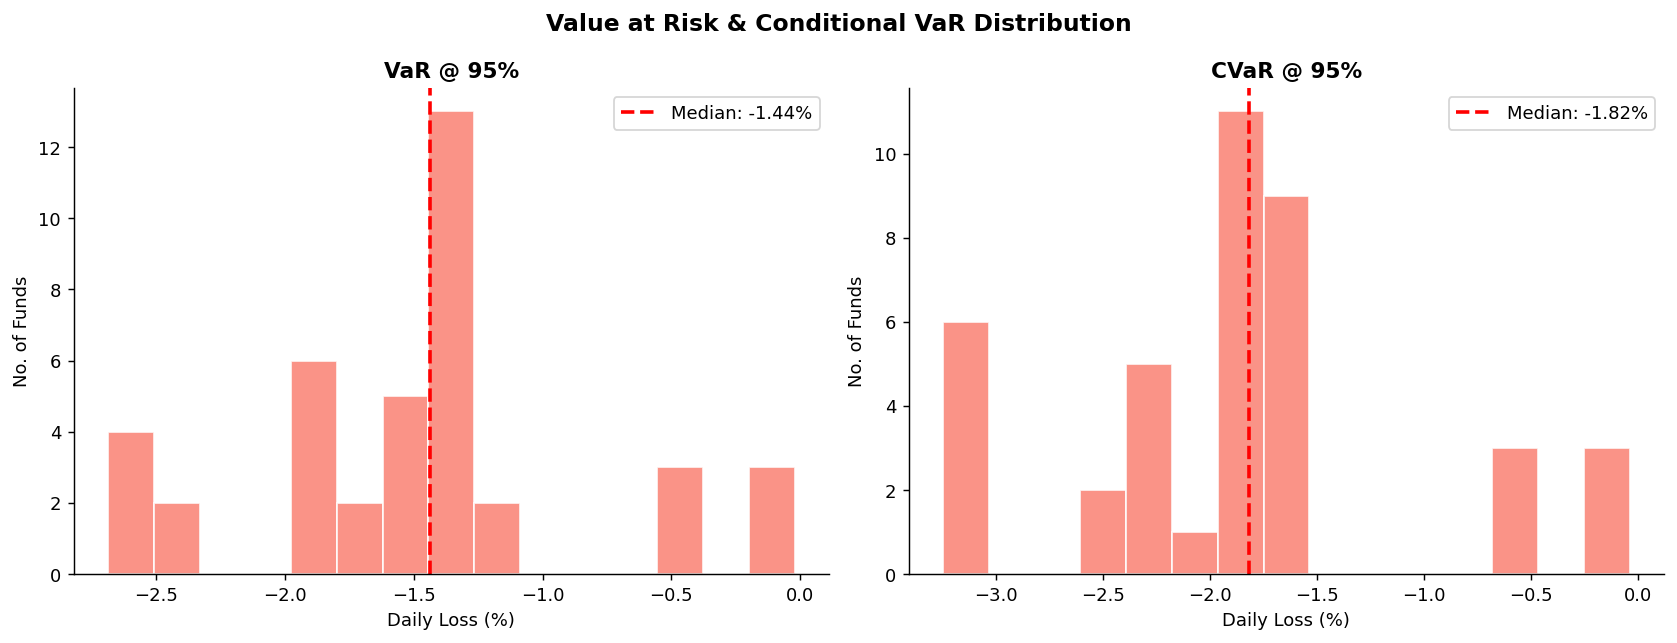

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, col, title in zip(axes, ["var_95","cvar_95"], ["VaR @ 95%","CVaR @ 95%"]):
    data = var_df[col].dropna()
    ax.hist(data, bins=15, color="salmon", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="red", linewidth=2, linestyle="--",
               label=f"Median: {data.median():.2f}%")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Daily Loss (%)"); ax.set_ylabel("No. of Funds")
    ax.legend()
plt.suptitle("Value at Risk & Conditional VaR Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RPT / "chart_adv01_var_cvar.png", dpi=150)
plt.show()

## 3. Rolling Sharpe – Industry Aggregate

In [4]:
nifty = bench[bench["index_name"].str.contains("NIFTY 50", case=False, na=False)].sort_values("date")
if len(nifty) > 63:
    rs = rolling_sharpe(nifty["daily_return_pct"], window=63)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(rs.index, rs, color="darkblue", linewidth=1.3)
    ax.axhline(0, color="gray", linestyle="--")
    ax.fill_between(rs.index, rs, 0, where=(rs>0), color="green", alpha=0.2)
    ax.fill_between(rs.index, rs, 0, where=(rs<0), color="red",   alpha=0.2)
    ax.set_title("NIFTY 50 – Rolling 63-Day Sharpe Ratio", fontweight="bold")
    ax.set_xlabel("Date"); ax.set_ylabel("Sharpe Ratio")
    plt.tight_layout()
    plt.savefig(RPT / "chart_adv02_rolling_sharpe_market.png", dpi=150)
    plt.show()
else:
    print("Insufficient NIFTY 50 data for rolling Sharpe.")

Insufficient NIFTY 50 data for rolling Sharpe.


## 4. Investor Cohort Analysis – Monthly Acquisition

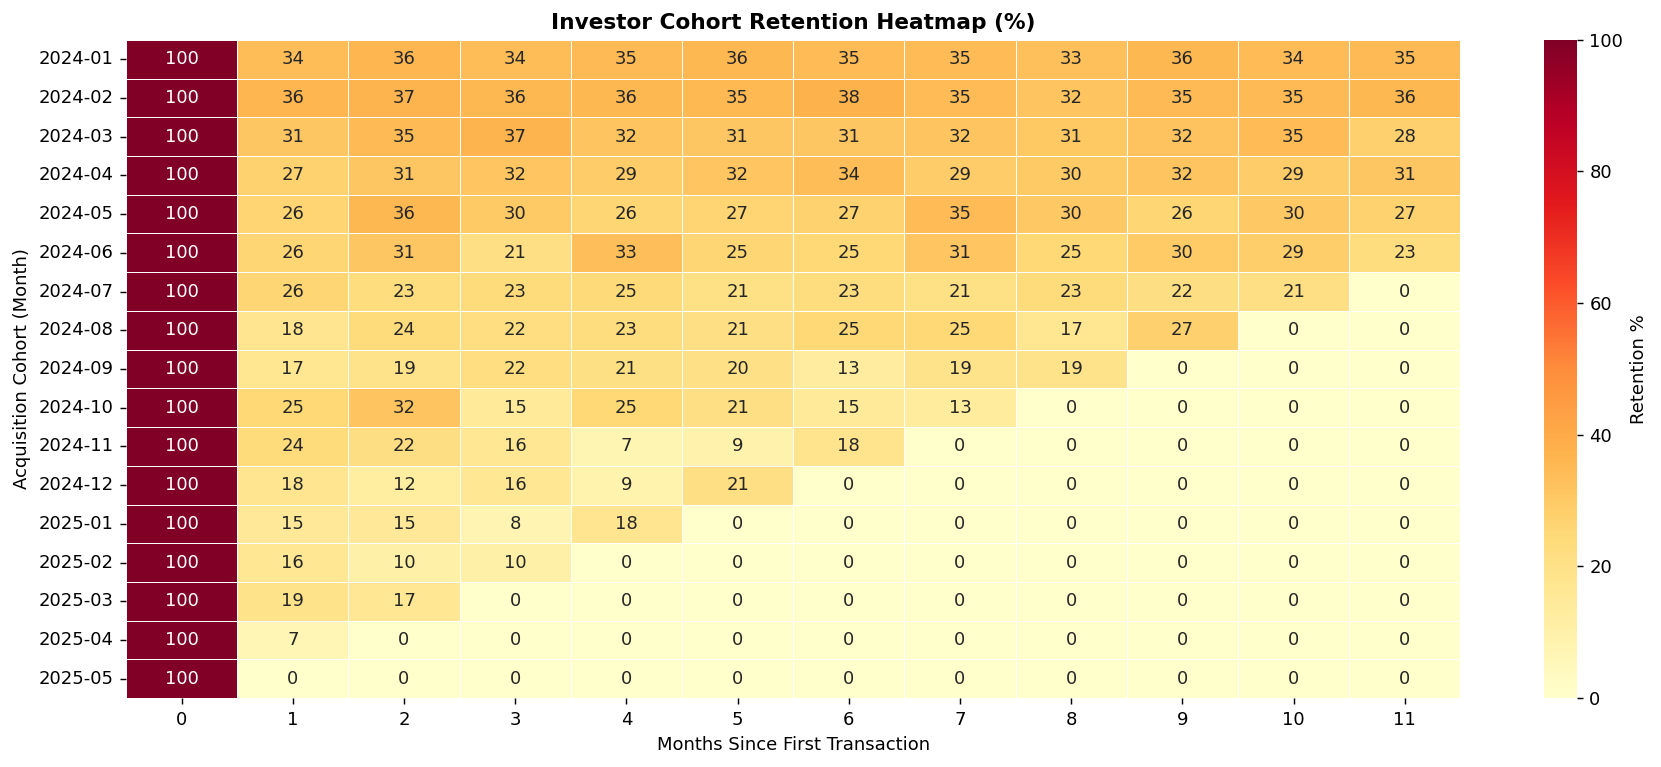

In [5]:
first_inv = txn.groupby("investor_id")["transaction_date"].min().reset_index()
first_inv.columns = ["investor_id","first_txn_date"]
first_inv["cohort"] = first_inv["first_txn_date"].dt.to_period("M")

txn2 = txn.merge(first_inv[["investor_id","cohort"]], on="investor_id")
txn2["txn_period"] = txn2["transaction_date"].dt.to_period("M")
txn2["periods_since_join"] = (txn2["txn_period"] - txn2["cohort"]).apply(lambda x: x.n)

cohort_pivot = txn2[txn2["periods_since_join"] >= 0].groupby(
    ["cohort","periods_since_join"])["investor_id"].nunique().unstack()

cohort_pct = cohort_pivot.div(cohort_pivot.iloc[:,0], axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
cmap = sns.color_palette("YlOrRd", as_cmap=True)
max_periods = min(cohort_pct.shape[1], 12)
sns.heatmap(cohort_pct.iloc[:, :max_periods].fillna(0), annot=True, fmt=".0f",
            cmap=cmap, ax=ax, linewidths=0.3, cbar_kws={"label":"Retention %"})
ax.set_title("Investor Cohort Retention Heatmap (%)", fontweight="bold")
ax.set_xlabel("Months Since First Transaction")
ax.set_ylabel("Acquisition Cohort (Month)")
plt.tight_layout()
plt.savefig(RPT / "chart_adv03_cohort_retention.png", dpi=150)
plt.show()

## 5. SIP Continuation Analysis

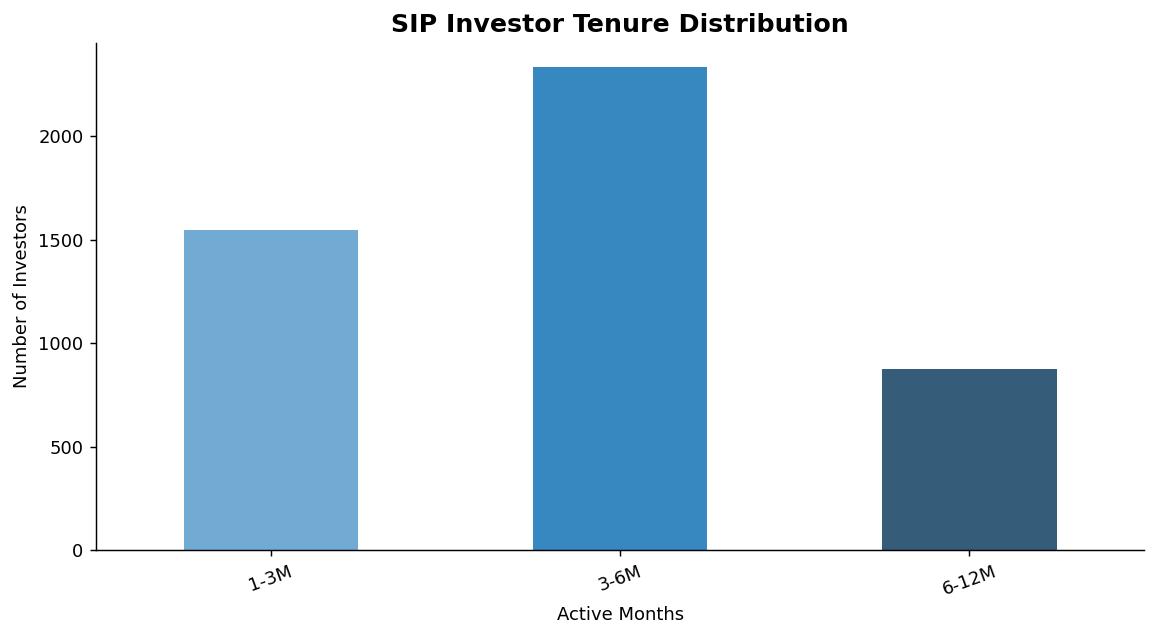

Maximum Active Months: 10
Chart Saved Successfully!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SIP Transactions Filter
sip_inv = txn[
    txn["transaction_type"]
    .astype(str)
    .str.upper()
    .str.contains("SIP", na=False)
].copy()

# Convert transaction_date to datetime
sip_inv["transaction_date"] = pd.to_datetime(
    sip_inv["transaction_date"],
    errors="coerce"
)

# Create Year-Month
sip_inv["year_month"] = sip_inv["transaction_date"].dt.to_period("M")

# Monthly SIP Activity
sip_active = (
    sip_inv.groupby(["investor_id", "year_month"])
    .size()
    .reset_index(name="sip_count")
)

# Count Active Months per Investor
sip_months = (
    sip_active.groupby("investor_id")["year_month"]
    .nunique()
    .reset_index()
)

sip_months.columns = ["investor_id", "active_months"]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

max_months = int(sip_months["active_months"].max())

# Safe bins generation
if max_months <= 3:
    bins = [1, max_months + 1]
    labels = ["1-3M"]

elif max_months <= 6:
    bins = [1, 3, max_months + 1]
    labels = ["1-3M", "3-6M"]

elif max_months <= 12:
    bins = [1, 3, 6, max_months + 1]
    labels = ["1-3M", "3-6M", "6-12M"]

elif max_months <= 24:
    bins = [1, 3, 6, 12, max_months + 1]
    labels = ["1-3M", "3-6M", "6-12M", "12-24M"]

elif max_months <= 36:
    bins = [1, 3, 6, 12, 24, max_months + 1]
    labels = ["1-3M", "3-6M", "6-12M", "12-24M", "24-36M"]

else:
    bins = [1, 3, 6, 12, 24, 36, max_months + 1]
    labels = ["1-3M", "3-6M", "6-12M", "12-24M", "24-36M", "36M+"]

# Create Buckets
sip_months["tenure_bucket"] = pd.cut(
    sip_months["active_months"],
    bins=bins,
    labels=labels,
    right=False
)

# Distribution
bucket_dist = (
    sip_months["tenure_bucket"]
    .value_counts()
    .sort_index()
)

# Plot Chart
bucket_dist.plot(
    kind="bar",
    ax=ax,
    color=sns.color_palette("Blues_d", len(labels))
)

ax.set_title(
    "SIP Investor Tenure Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Active Months")
ax.set_ylabel("Number of Investors")

ax.tick_params(axis="x", rotation=20)

plt.tight_layout()

# Save Chart
plt.savefig(
    RPT / "chart_adv04_sip_tenure.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Maximum Active Months:", max_months)
print("Chart Saved Successfully!")

## 6. Fund Recommendation Engine

In [7]:
from recommender import recommend, print_recommendations

for appetite in ["Low", "Moderate", "High"]:
    print_recommendations(appetite)
    recs = recommend(appetite)
    recs.to_csv(PROC / f"recommendations_{appetite.lower()}.csv", index=True, index_label="rank")
    print(f"  Saved: recommendations_{appetite.lower()}.csv\n")


  Bluestock MF Recommender – Risk Appetite: LOW

  #1  Kotak Liquid Fund - Regular - Growth
       Fund House   : Kotak Mahindra MF
       Category     : Liquid (Regular)
       1Y / 3Y Ret  : 4.26% / 6.18%
       Sharpe Ratio : 6.18
       Max Drawdown : -3.81%
       AUM (Cr)     : ₹27,623
       Score        : 0.6457

  #2  ICICI Pru Liquid Fund - Regular - Growth
       Fund House   : ICICI Prudential MF
       Category     : Liquid (Regular)
       1Y / 3Y Ret  : 8.89% / 7.68%
       Sharpe Ratio : 7.68
       Max Drawdown : -2.62%
       AUM (Cr)     : ₹39,116
       Score        : 0.6000

  #3  ABSL Liquid Fund - Regular - Growth
       Fund House   : Aditya Birla Sun Life MF
       Category     : Liquid (Regular)
       1Y / 3Y Ret  : 6.18% / 5.14%
       Sharpe Ratio : 5.14
       Max Drawdown : -3.66%
       AUM (Cr)     : ₹38,995
       Score        : 0.3496


  Saved: recommendations_low.csv


  Bluestock MF Recommender – Risk Appetite: MODERATE

  #1  ICICI Pru Bluechip F

## 7. Sector Concentration Risk

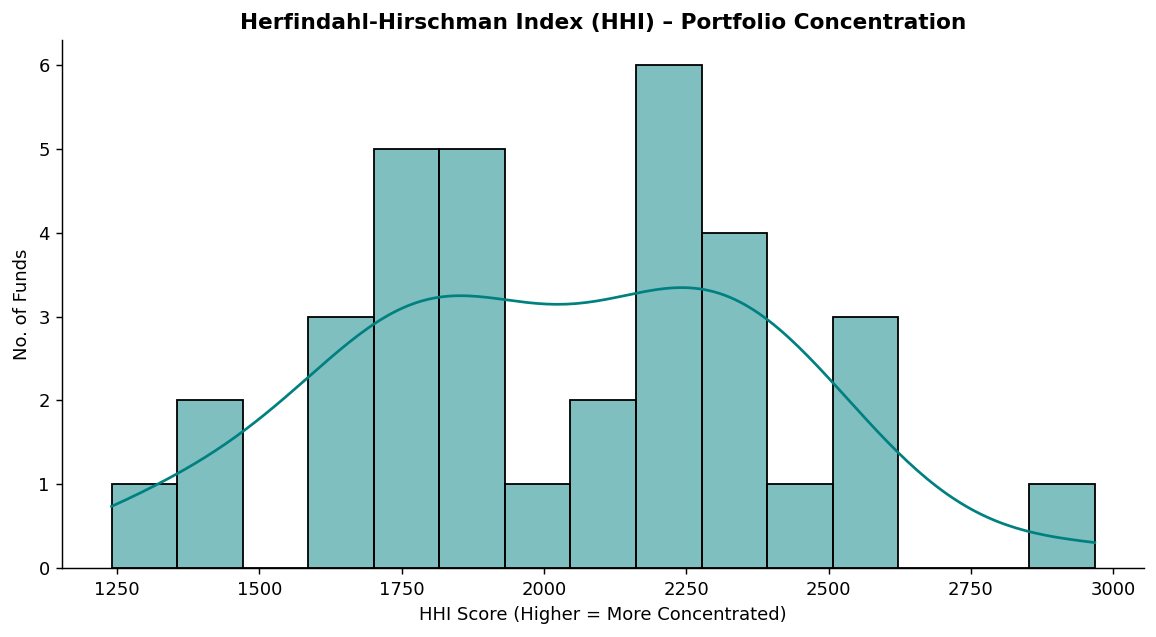


Most concentrated fund:
                                      scheme_name  hhi_score
            Axis Bluechip Fund - Regular - Growth  2967.6909
    Mirae Asset Tax Saver Fund - Regular - Growth  2549.9194
HDFC Mid-Cap Opportunities Fund - Direct - Growth  2531.5500


In [8]:
sector_conc = hold.groupby(["amfi_code","sector"])["weight_pct"].sum().reset_index()
sector_hhi = sector_conc.groupby("amfi_code").apply(
    lambda g: (g["weight_pct"]**2).sum()
).reset_index(name="hhi_score")
sector_hhi = sector_hhi.merge(sp[["amfi_code","scheme_name","category"]], on="amfi_code", how="left")

fig, ax = plt.subplots(figsize=(9,5))
sns.histplot(data=sector_hhi, x="hhi_score", bins=15, kde=True, ax=ax, color="teal")
ax.set_title("Herfindahl-Hirschman Index (HHI) – Portfolio Concentration", fontweight="bold")
ax.set_xlabel("HHI Score (Higher = More Concentrated)")
ax.set_ylabel("No. of Funds")
plt.tight_layout()
plt.savefig(RPT / "chart_adv05_sector_hhi.png", dpi=150)
plt.show()
print(f"\nMost concentrated fund:\n{sector_hhi.nlargest(3,'hhi_score')[['scheme_name','hhi_score']].to_string(index=False)}")

## 8. Power BI-Ready Dataset Export

In [9]:
# Merge key tables into a flat, analytics-ready dataset
pbi = txn.merge(sp[["amfi_code","scheme_name","fund_house","category","return_3yr_pct",
                      "sharpe_ratio","risk_grade","aum_crore"]], on="amfi_code", how="left")
pbi.to_csv(PROC / "powerbi_investor_fund_flat.csv", index=False)

sip_pbi = sip.copy()
sip_pbi.to_csv(PROC / "powerbi_sip_trends.csv", index=False)

print("Power BI-ready files exported:")
print(f"  powerbi_investor_fund_flat.csv : {len(pbi):,} rows")
print(f"  powerbi_sip_trends.csv          : {len(sip_pbi):,} rows")
print("\nAdvanced Analytics Notebook Complete!")

Power BI-ready files exported:
  powerbi_investor_fund_flat.csv : 32,778 rows
  powerbi_sip_trends.csv          : 48 rows

Advanced Analytics Notebook Complete!
